# 05 — Baseline vs four LoRAs: full comparison

**No GPU required.** Run **top to bottom** once.

Compares the **baseline** checkpoint to four LoRA variants on the **same prompts** for every dimension:

| Model | Stats file |
|-------|------------|
| `base` | `stats_base_v2.json` (+ optional shard) |
| `l1` | `stats_lora_l1.json` |
| `l2` | `stats_lora_l2.json` |
| `l1_l2` | `stats_lora_combined.json` (L1+L2 combined) |
| `l3` | `stats_lora_l3_tri_num.json` |

**Prompt set:** strict intersection of succeeded `prompt_id` across all five — `common_ids_all`.

**Sections:**  
0. Paths · 1. Load + intersection · 2. First-token (argmax + softmax) · 3. Scalar Δ vs base · 4. Mean Δ by group · 5. Δ distributions · 6. Top-20 Jaccard · 7. Logit gap · 8. LOFO classifiers (§5/§5b) · 9. LOFO summary chart · 10. Thesis metrics table · 11. Export CSVs

*Thesis question:* does T/F fine-tuning shift structure toward content (family×label) vs format (tail)?


## 0 — Environment setup

In [1]:
import os
import sys
from pathlib import Path

def _find_repo_root():
    start = Path.cwd().resolve()
    for directory in [start, *start.parents]:
        if (directory / "circuit_tracer" / "__init__.py").is_file():
            return directory
    workspace = Path("/workspace")
    if workspace.is_dir():
        for child in workspace.iterdir():
            if child.is_dir() and (child / "circuit_tracer" / "__init__.py").is_file():
                return child
    repo_override = os.environ.get("CT_REPO_DIR")
    if repo_override:
        override_path = Path(repo_override).expanduser().resolve()
        if (override_path / "circuit_tracer" / "__init__.py").is_file():
            return override_path
    return None

_root = _find_repo_root()
if _root is not None:
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))
    _my_work = _root / "my_work"
    if str(_my_work) not in sys.path:
        sys.path.insert(0, str(_my_work))
    print(f"Repo root: {_root}")
else:
    print("WARNING: could not locate circuit_tracer repo. Set CT_REPO_DIR.")

MY_WORK = _my_work if _root else Path(".").resolve()
STATS_DIR = MY_WORK / "results" / "statistics"
FIGURES_DIR = MY_WORK / "results" / "figures" / "lora_comparison"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FIRST_TOKEN_DIR = MY_WORK / "results" / "first_token"

print(f"MY_WORK    : {MY_WORK}")
print(f"STATS_DIR  : {STATS_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")


Repo root: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main
MY_WORK    : /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work
STATS_DIR  : /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/statistics
FIGURES_DIR: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison


## 1 — Load all models + N-way intersection

Registers **base + l1 + l2 + l1_l2 + l3**, merges baseline shards, loads each stats JSON,
and keeps only `prompt_id` present in **all** phases with `attribution_succeeded`.

Outputs: `PHASE_REGISTRY`, `phase_stats_by_id`, `common_ids_all`, helpers.


In [2]:
import importlib
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

matplotlib.rcParams["figure.dpi"] = 110

import utils.graph_statistics as gs_mod
importlib.reload(gs_mod)
import utils.structural_classification as sc_mod
importlib.reload(sc_mod)

from utils.structural_classification import TF_FAMILIES, eval_phase_lofo
from utils.graph_statistics import load_statistics, _flatten_nested, _binary_label_true


def _label_str(s) -> str:
    lbl = s.get("label")
    try:
        return "true" if _binary_label_true(lbl) else "false"
    except Exception:
        return str(lbl)


# ── Phase registry: (key, [stats_paths], pred_csv, binary_probs, numeric_digit_probs)
PHASE_REGISTRY = [
    (
        "base",
        [
            STATS_DIR / "stats_base_v2.json",
            STATS_DIR / "stats_base_v2_from160.json",
        ],
        FIRST_TOKEN_DIR / "base_v2_predictions.csv",
        FIRST_TOKEN_DIR / "base_v2_binary_token_probs.csv",
        FIRST_TOKEN_DIR / "base_v2_numeric_digit_probs.csv",
    ),
    (
        "l1",
        [STATS_DIR / "stats_lora_l1.json"],
        FIRST_TOKEN_DIR / "lora_l1_predictions.csv",
        FIRST_TOKEN_DIR / "lora_binary_token_probs_lora_l1.csv",
        FIRST_TOKEN_DIR / "lora_numeric_digit_probs_lora_l1.csv",
    ),
    (
        "l2",
        [STATS_DIR / "stats_lora_l2.json"],
        FIRST_TOKEN_DIR / "lora_l2_predictions.csv",
        FIRST_TOKEN_DIR / "lora_binary_token_probs_lora_l2.csv",
        FIRST_TOKEN_DIR / "lora_numeric_digit_probs_lora_l2.csv",
    ),
    (
        "l1_l2",
        [STATS_DIR / "stats_lora_combined.json"],
        FIRST_TOKEN_DIR / "lora_combined_predictions.csv",
        FIRST_TOKEN_DIR / "lora_binary_token_probs_lora_combined.csv",
        FIRST_TOKEN_DIR / "lora_numeric_digit_probs_lora_combined.csv",
    ),
    (
        "l3",
        [STATS_DIR / "stats_lora_l3_tri_num.json"],
        FIRST_TOKEN_DIR / "lora_l3_tri_num_predictions.csv",
        FIRST_TOKEN_DIR / "lora_binary_token_probs_lora_l3_tri_num.csv",
        FIRST_TOKEN_DIR / "lora_numeric_digit_probs_lora_l3_tri_num.csv",
    ),
]


def _merge_shard_lists_to_by_id(*lists):
    merged: dict = {}
    for lst in lists:
        for row in lst:
            pid = row.get("prompt_id")
            if pid is None:
                continue
            if pid not in merged:
                merged[pid] = row
            else:
                old_ok = bool(merged[pid].get("attribution_succeeded"))
                new_ok = bool(row.get("attribution_succeeded"))
                if new_ok and not old_ok:
                    merged[pid] = row
                elif not old_ok and not new_ok:
                    merged[pid] = row
    return merged


def _load_phase_stats(stats_paths):
    shards = []
    for p in stats_paths:
        p = Path(p)
        if p.exists():
            shards.append(load_statistics(p))
        else:
            print(f"  WARNING: missing stats file {p.name}")
    return _merge_shard_lists_to_by_id(*shards) if shards else {}


phase_stats_by_id: dict[str, dict] = {}

print(f"{'Phase':<12}  {'ok rows':>10}  {'binary TF':>10}")
print("-" * 38)
for name, stat_paths, _pred, _bin_prob, _num_prob in PHASE_REGISTRY:
    by_id = {
        pid: row
        for pid, row in _load_phase_stats(stat_paths).items()
        if row.get("attribution_succeeded")
    }
    phase_stats_by_id[name] = by_id
    n_tf = sum(
        1 for r in by_id.values()
        if r.get("task_type", "binary") == "binary" and r.get("family") in TF_FAMILIES
    )
    print(f"{name:<12}  {len(by_id):>10}  {n_tf:>10}")

phase_names_all = [name for name, *_ in PHASE_REGISTRY]
common_ids_all: set[str] = set(phase_stats_by_id[phase_names_all[0]].keys())
for name in phase_names_all[1:]:
    common_ids_all &= set(phase_stats_by_id[name].keys())

common_ids = sorted(common_ids_all)
LORA_PHASES = [n for n, *_ in PHASE_REGISTRY if n != "base"]

print()
print(f"N-way intersection (base + 4 LoRA): {len(common_ids_all)} prompts")

n_tf_common = sum(
    1 for pid in common_ids_all
    if phase_stats_by_id["base"][pid].get("task_type", "binary") == "binary"
    and phase_stats_by_id["base"][pid].get("family") in TF_FAMILIES
)
print(f"Binary T/F rows (from base metadata):  {n_tf_common} prompts")

# Quick slice table (same spirit as old §1)
fam_lbl = Counter(
    (phase_stats_by_id["base"][pid].get("family", "?"), _label_str(phase_stats_by_id["base"][pid]),
     phase_stats_by_id["base"][pid].get("tail", "?"))
    for pid in common_ids
)
print()
print(f"{'family':<24} {'label':<8} {'tail':<22} {'n':>4}")
print("-" * 62)
for (fam, lbl, tail), cnt in sorted(fam_lbl.items()):
    print(f"{fam:<24} {lbl:<8} {tail:<22} {cnt:>4}")


Phase            ok rows   binary TF
--------------------------------------
base                 300         270
l1                   266         238
l2                   259         232
l1_l2                300         270
l3                   240         214

N-way intersection (base + 4 LoRA): 240 prompts
Binary T/F rows (from base metadata):  214 prompts

family                   label    tail                      n
--------------------------------------------------------------
geometry_claim           false    answer_colon              6
geometry_claim           false    the_answer_is             5
geometry_claim           false    true_or_false             6
geometry_claim           true     answer_colon              5
geometry_claim           true     the_answer_is             5
geometry_claim           true     true_or_false             5
numeric_open             true     answer_colon             26
numeric_validity         false    answer_colon             25
numeric_validity 

## 2 — First-token: argmax + softmax (binary vs numeric, all phases)

Same spirit as **`03_baseline_structural_analysis` §4**: split **`task_type`** into **binary**
(True/False) and **numeric** (digit answer).

**Binary — argmax:** full-vocab greedy token vs gold (`is_correct` in predictions CSV); split by T/F via
`expected_token_id` (5569 / 7662) when present.

**Binary — softmax:** `*_binary_token_probs.csv` — restricted T/F lane; accuracy when
`prob_true > prob_false` matches gold; **tf_margin** = \(P(\text{correct TF}) - P(\text{wrong TF})\)
(same construction as `03`).

**Numeric — argmax:** `is_correct` on `task_type == "numeric"` rows only.

**Numeric — softmax:** `*_numeric_digit_probs.csv` — the **ten digit bins** `prob_digit_0` … `prob_digit_9` (same restricted lane as **`03` §4.3**):

- **digit_margin** = \(2 \cdot P(\text{correct}) - \sum_{k=0}^{9} P(k)\); **sm_pos** = fraction of rows with **digit_margin > 0** (correct digit beats the other nine combined — **`03`** calls this **`frac_margin_pos`** in grouped tables).
- **sm_top1** = fraction where **argmax\(_k\) prob_digit_k** equals the gold digit (10-way readout from the same softmax slice; analogue of binary **sm_acc** but over ten logits).

All rows restricted to **`common_ids_all`**.


In [3]:
import math as _math

import numpy as np

_VOCAB_TRUE = 5569
_VOCAB_FALSE = 7662
DIGIT_COLS = [f"prob_digit_{d}" for d in range(10)]


def _argmax_metrics(pred_csv: Path, common: set) -> dict:
    '''Argmax (full vocabulary) from predictions CSV; split binary / numeric.'''
    if not pred_csv.exists():
        return {"_missing": True}
    df = pd.read_csv(pred_csv, dtype={"prompt_id": str})
    df = df[df["prompt_id"].isin(common)]
    if df.empty:
        return {"_empty": True}
    ic = "is_correct"
    overall = float(df[ic].mean()) if ic in df.columns else float("nan")
    tt_col = "task_type" if "task_type" in df.columns else None
    if tt_col:
        bin_df = df[df[tt_col].astype(str) == "binary"]
        num_df = df[df[tt_col].astype(str) != "binary"]
    else:
        bin_df = df
        num_df = pd.DataFrame()
    bin_acc = float(bin_df[ic].mean()) if len(bin_df) else float("nan")
    true_acc = false_acc = float("nan")
    if len(bin_df) and ic in bin_df.columns:
        if "expected_token_id" in bin_df.columns:
            eid = pd.to_numeric(bin_df["expected_token_id"], errors="coerce")
            m_t = eid == _VOCAB_TRUE
            m_f = eid == _VOCAB_FALSE
            if m_t.any():
                true_acc = float(bin_df.loc[m_t, ic].mean())
            if m_f.any():
                false_acc = float(bin_df.loc[m_f, ic].mean())
        elif "label" in bin_df.columns:
            ll = bin_df["label"].astype(str).str.strip().str.lower()
            m_t = ll == "true"
            m_f = ll == "false"
            if m_t.any():
                true_acc = float(bin_df.loc[m_t, ic].mean())
            if m_f.any():
                false_acc = float(bin_df.loc[m_f, ic].mean())
    num_acc = float(num_df[ic].mean()) if len(num_df) and ic in num_df.columns else float("nan")
    return {
        "n": len(df), "overall": overall, "binary": bin_acc, "true_acc": true_acc, "false_acc": false_acc,
        "numeric": num_acc, "n_binary": len(bin_df), "n_numeric": len(num_df),
    }


def _softmax_binary_metrics(bin_csv: Path, common: set) -> dict:
    '''T/F softmax lane only (binary_token_probs CSV). Aligned with 03 notebook §4.'''
    if not bin_csv.exists():
        return {"_missing": True}
    df = pd.read_csv(bin_csv, dtype={"prompt_id": str})
    df = df[df["prompt_id"].isin(common)]
    if "task_type" in df.columns:
        df = df[df["task_type"].astype(str) == "binary"]
    if df.empty:
        return {"_empty": True}
    df["_gold_true"] = df["label"].astype(str).str.strip().str.lower() == "true"
    df["_sm_correct"] = (
        (df["_gold_true"] & (df["prob_true"] > df["prob_false"]))
        | (~df["_gold_true"] & (df["prob_false"] > df["prob_true"]))
    )
    sm_acc = float(df["_sm_correct"].mean())
    eps = 1e-12
    df["_log_p_correct"] = np.where(
        df["_gold_true"],
        np.log(df["prob_true"].astype(float) + eps),
        np.log(df["prob_false"].astype(float) + eps),
    )
    mean_log_p = float(np.mean(df["_log_p_correct"]))
    p_corr = np.where(df["_gold_true"], df["prob_true"].astype(float), df["prob_false"].astype(float))
    p_wrong = np.where(df["_gold_true"], df["prob_false"].astype(float), df["prob_true"].astype(float))
    tf_margin = p_corr - p_wrong
    mean_tf_margin = float(np.mean(tf_margin))
    gt = df[df["_gold_true"]]
    gf = df[~df["_gold_true"]]
    true_sm = float(gt["_sm_correct"].mean()) if len(gt) else float("nan")
    false_sm = float(gf["_sm_correct"].mean()) if len(gf) else float("nan")
    return {
        "n_binary": len(df), "sm_acc": sm_acc, "true_sm": true_sm, "false_sm": false_sm,
        "mean_log_p": mean_log_p, "mean_tf_margin": mean_tf_margin,
    }


def _softmax_numeric_metrics(num_csv: Path, common: set) -> dict:
    '''Digit softmax (numeric_digit_probs CSV). digit_margin as in 03 notebook §4.'''
    if not num_csv.exists():
        return {"_missing": True}
    df = pd.read_csv(num_csv, dtype={"prompt_id": str})
    df = df[df["prompt_id"].isin(common)]
    if "task_type" in df.columns:
        df = df[df["task_type"].astype(str) == "numeric"]
    if df.empty:
        return {"_empty": True}
    miss = [c for c in DIGIT_COLS + ["prob_mass_digits", "label"] if c not in df.columns]
    if miss:
        return {"_error": f"missing columns {miss}"}
    _lbl = pd.to_numeric(df["label"], errors="coerce").fillna(-1).astype(int)
    valid = (_lbl >= 0) & (_lbl <= 9)
    df = df.loc[valid].copy()
    _lbl = _lbl.loc[valid].to_numpy()
    if len(df) == 0:
        return {"_empty": True}
    mat = df[DIGIT_COLS].to_numpy(dtype=float)
    ri = np.arange(len(df))
    p_correct = mat[ri, _lbl]
    mass = df["prob_mass_digits"].to_numpy(dtype=float)
    digit_margin = 2.0 * p_correct - mass
    mean_margin = float(np.mean(digit_margin))
    frac_margin_pos = float(np.mean(digit_margin > 0))
    pred_digit = np.argmax(mat, axis=1)
    sm_top1_digit = float(np.mean(pred_digit == _lbl))
    mean_log_p_digit = float(np.mean(np.log(p_correct + 1e-12)))
    return {
        "n_numeric": len(df),
        "mean_digit_margin": mean_margin,
        "frac_margin_pos": frac_margin_pos,
        "sm_top1_digit": sm_top1_digit,
        "mean_log_p_digit": mean_log_p_digit,
    }


binary_rows = []
numeric_rows = []
compact_rows = []

for name, stat_paths, pred_csv, bin_csv, num_csv in PHASE_REGISTRY:
    am = _argmax_metrics(pred_csv, common_ids_all)
    smb = _softmax_binary_metrics(bin_csv, common_ids_all)
    smn = _softmax_numeric_metrics(num_csv, common_ids_all)

    binary_rows.append({
        "phase": name,
        "n_bin_argmax": am.get("n_binary", 0),
        "argmax_bin": am.get("binary", float("nan")),
        "argmax_T": am.get("true_acc", float("nan")),
        "argmax_F": am.get("false_acc", float("nan")),
        "n_bin_soft": smb.get("n_binary", "–"),
        "sm_acc": smb.get("sm_acc", float("nan")),
        "sm_T": smb.get("true_sm", float("nan")),
        "sm_F": smb.get("false_sm", float("nan")),
        "mean_log_p_TF": smb.get("mean_log_p", float("nan")),
        "mean_tf_margin": smb.get("mean_tf_margin", float("nan")),
    })
    numeric_rows.append({
        "phase": name,
        "n_num_argmax": am.get("n_numeric", 0),
        "argmax_numeric": am.get("numeric", float("nan")),
        "n_num_soft": smn.get("n_numeric", "–"),
        "sm_top1_digit": smn.get("sm_top1_digit", float("nan")),
        "mean_digit_margin": smn.get("mean_digit_margin", float("nan")),
        "frac_margin_pos": smn.get("frac_margin_pos", float("nan")),
        "mean_log_p_digit": smn.get("mean_log_p_digit", float("nan")),
    })
    compact_rows.append({
        "phase": name,
        "n_argmax": am.get("n", "–"),
        "argmax_overall": am.get("overall", float("nan")),
        "argmax_binary": am.get("binary", float("nan")),
        "argmax_numeric": am.get("numeric", float("nan")),
        "sm_bin_acc": smb.get("sm_acc", float("nan")),
        "sm_num_top1": smn.get("sm_top1_digit", float("nan")),
        "sm_num_margin_pos": smn.get("frac_margin_pos", float("nan")),
        "mean_log_p_TF": smb.get("mean_log_p", float("nan")),
    })

df_token_binary = pd.DataFrame(binary_rows).set_index("phase")
df_token_numeric = pd.DataFrame(numeric_rows).set_index("phase")
df_token = pd.DataFrame(compact_rows).set_index("phase")


def _pct(v):
    return f"{v:.1%}" if not (isinstance(v, float) and (_math.isnan(v))) else "  N/A"


print("=" * 88)
print("BINARY (True/False) — restricted to common_ids_all")
print("=" * 88)
hdr_b = (
    f"{'Phase':<10} | {'n_arg':>5} {'arg_bin':>8} {'arg_T':>7} {'arg_F':>7} | "
    f"{'n_sm':>5} {'sm_acc':>7} {'sm_T':>6} {'sm_F':>6} {'m_TF_marg':>9} {'mlogP':>8}"
)
print(hdr_b)
print("-" * len(hdr_b))
for _, r in df_token_binary.iterrows():
    mm = r["mean_tf_margin"]
    mms = f"{mm:>9.4f}" if not (_math.isnan(mm)) else f"{'N/A':>9}"
    mlp = r["mean_log_p_TF"]
    mlps = f"{mlp:>8.3f}" if not (_math.isnan(mlp)) else f"{'N/A':>8}"
    print(
        f"{r.name:<10} | {int(r['n_bin_argmax']):>5} {_pct(r['argmax_bin']):>8} "
        f"{_pct(r['argmax_T']):>7} {_pct(r['argmax_F']):>7} | "
        f"{str(r['n_bin_soft']):>5} {_pct(r['sm_acc']):>7} {_pct(r['sm_T']):>6} {_pct(r['sm_F']):>6} "
        f"{mms} {mlps}"
    )

print()
print("=" * 88)
print("NUMERIC (digit softmax slice) — restricted to common_ids_all")
print("=" * 88)
hdr_n = (
    f"{'Phase':<10} | {'n_arg':>5} {'argmax':>8} | {'n_sm':>5} "
    f"{'sm_top1':>8} {'mean_marg':>10} {'sm_pos':>7} {'mlogP_d':>9}"
)
print(hdr_n)
print("-" * len(hdr_n))
for _, r in df_token_numeric.iterrows():
    mm = r["mean_digit_margin"]
    mms = f"{mm:>10.5f}" if not (_math.isnan(mm)) else f"{'N/A':>10}"
    st1 = r["sm_top1_digit"]
    st1s = _pct(st1) if not (_math.isnan(st1)) else "  N/A"
    pp = r["frac_margin_pos"]
    pps = _pct(pp) if not (_math.isnan(pp)) else "  N/A"
    mlp = r["mean_log_p_digit"]
    mlps = f"{mlp:>9.4f}" if not (_math.isnan(mlp)) else f"{'N/A':>9}"
    print(
        f"{r.name:<10} | {int(r['n_num_argmax']):>5} {_pct(r['argmax_numeric']):>8} | "
        f"{str(r['n_num_soft']):>5} {st1s:>8} {mms} {pps:>7} {mlps}"
    )

print()
print("Compact (overall + binary sm_acc; numeric sm_top1 + sm_pos / frac_margin_pos):")
print(df_token.to_string())



BINARY (True/False) — restricted to common_ids_all
Phase      | n_arg  arg_bin   arg_T   arg_F |  n_sm  sm_acc   sm_T   sm_F m_TF_marg    mlogP
--------------------------------------------------------------------------------------------
base       |   214    18.2%   18.5%   17.9% | 214.0   73.8% 100.0%  47.2%    0.0249   -4.352
l1         |   214    64.5%     N/A     N/A | 214.0   64.5%  75.9%  52.8%    0.2346   -1.192
l2         |   214    74.8%     N/A     N/A | 214.0   70.1%  57.4%  83.0%    0.3472   -0.614
l1_l2      |   214    48.6%     N/A     N/A | 214.0   64.5%  50.0%  79.2%    0.2794   -1.050
l3         |   214     0.0%     N/A     N/A | 214.0   61.7%  86.1%  36.8%   -0.0014  -14.125

NUMERIC (digit) — restricted to common_ids_all
Phase      | n_arg   argmax |  n_sm  mean_marg    %pos   mlogP_d
----------------------------------------------------------------
base       |    26     0.0% |  26.0   -0.00441    0.0%   -7.9527
l1         |    26     0.0% |  26.0   -0.00019    0.0% 

## 3 — Scalar metric deltas vs baseline (each LoRA)


In [4]:
# Build union of scalar metric keys from flattened base sample
_base0 = _flatten_nested(next(iter(phase_stats_by_id["base"].values())))
_BASE_SCALAR = [
    "n_active_features", "edge_density", "mean_top50_score", "top10_over_top50", "layer_entropy",
    "mean_error_node_weight", "logit_gap", "layer_stats_mean", "layer_stats_std", "layer_stats_median",
    "layer_stats_entropy_bits", "topk20_score_total", "topk20_score_gini",
]
_prune_prefixes = ("density_at_", "n_kept_at_", "n_edges_at_", "n_nodes_total_at_", "n_edges_total_at_")
_prune_cols = sorted(
    k for k in _base0 if k.startswith(_prune_prefixes)
)
SCALAR_METRICS = _BASE_SCALAR + _prune_cols

delta_rows: list[dict] = []
base_by_id = phase_stats_by_id["base"]
for lora_name in LORA_PHASES:
    l_by_id = phase_stats_by_id[lora_name]
    for pid in common_ids:
        b = base_by_id[pid]
        l = l_by_id[pid]
        bf = _flatten_nested(b)
        lf = _flatten_nested(l)
        row = {
            "phase": lora_name,
            "prompt_id": pid,
            "family": b.get("family", "?"),
            "tail": b.get("tail", "?"),
            "label": _label_str(b),
        }
        for m in SCALAR_METRICS:
            bv = bf.get(m)
            lv = lf.get(m)
            if bv is not None and lv is not None:
                try:
                    row[f"d_{m}"] = float(lv) - float(bv)
                except (TypeError, ValueError):
                    pass
        delta_rows.append(row)

df_delta = pd.DataFrame(delta_rows)
delta_cols = [c for c in df_delta.columns if c.startswith("d_")]

KEY_METRICS = [
    "d_n_active_features", "d_logit_gap", "d_edge_density",
    "d_layer_stats_mean", "d_layer_stats_entropy_bits",
    "d_topk20_score_total", "d_topk20_score_gini", "d_mean_error_node_weight",
]
KEY_METRICS = [m for m in KEY_METRICS if m in df_delta.columns]

print(f"Per-prompt Δ rows: {len(df_delta)}  (={len(common_ids)} prompts × {len(LORA_PHASES)} LoRAs)")
print(f"Delta metric columns: {len(delta_cols)}")
print()
print("Mean Δ (LoRA − base) by LoRA:")
print("-" * 72)
for lora_name in LORA_PHASES:
    sub = df_delta[df_delta["phase"] == lora_name]
    print(f"\n[{lora_name}]")
    for dc in KEY_METRICS[:8]:
        col = sub[dc].dropna()
        if len(col):
            print(f"  {dc[2:]:<32} mean={col.mean():>+12.4f}")


Per-prompt Δ rows: 960  (=240 prompts × 4 LoRAs)
Delta metric columns: 48

Mean Δ (LoRA − base) by LoRA:
------------------------------------------------------------------------

[l1]
  n_active_features                mean=   +680.5042
  logit_gap                        mean=     -0.6933
  edge_density                     mean=     -0.0027
  layer_stats_mean                 mean=     -0.2334
  layer_stats_entropy_bits         mean=     -0.0103
  topk20_score_total               mean=     +0.1658
  topk20_score_gini                mean=     +0.1258
  mean_error_node_weight           mean=     +0.0071

[l2]
  n_active_features                mean=   -119.4958
  logit_gap                        mean=     -1.2430
  edge_density                     mean=     -0.0079
  layer_stats_mean                 mean=     -0.1377
  layer_stats_entropy_bits         mean=     -0.0037
  topk20_score_total               mean=     +0.1632
  topk20_score_gini                mean=     +0.1560
  mean_error_no

## 4 — Mean Δ by (family, label, tail) — per LoRA


In [5]:
KEY_GROUP_METRICS = [m for m in KEY_METRICS if m in df_delta.columns]

for lora_name in LORA_PHASES:
    sub = df_delta[df_delta["phase"] == lora_name]
    print(f"\n=== [{lora_name}] Mean Δ by (family, label) ===")
    try:
        print(sub.groupby(["family", "label"])[KEY_GROUP_METRICS].mean().to_string(float_format=lambda x: f"{x:+.4f}"))
    except Exception as e:
        print(f"  Error: {e}")



=== [l1] Mean Δ by (family, label) ===
                        d_n_active_features  d_logit_gap  d_edge_density  d_layer_stats_mean  d_layer_stats_entropy_bits  d_topk20_score_total  d_topk20_score_gini  d_mean_error_node_weight
family           label                                                                                                                                                                       
geometry_claim   false            +668.2353      +0.6071         -0.0100             -0.2304                     -0.0154               +0.1901              +0.1432                   +0.0059
                 true             +680.1333      +2.5108         -0.0092             -0.2373                     -0.0162               +0.2001              +0.1313                   +0.0056
numeric_open     true             +573.6538      -2.8629         -0.0022             -0.2287                     -0.0080               -0.0000              +0.0319                   -0.0116
numeric_va

## 5 — Distributions of Δ vs baseline (key metrics)


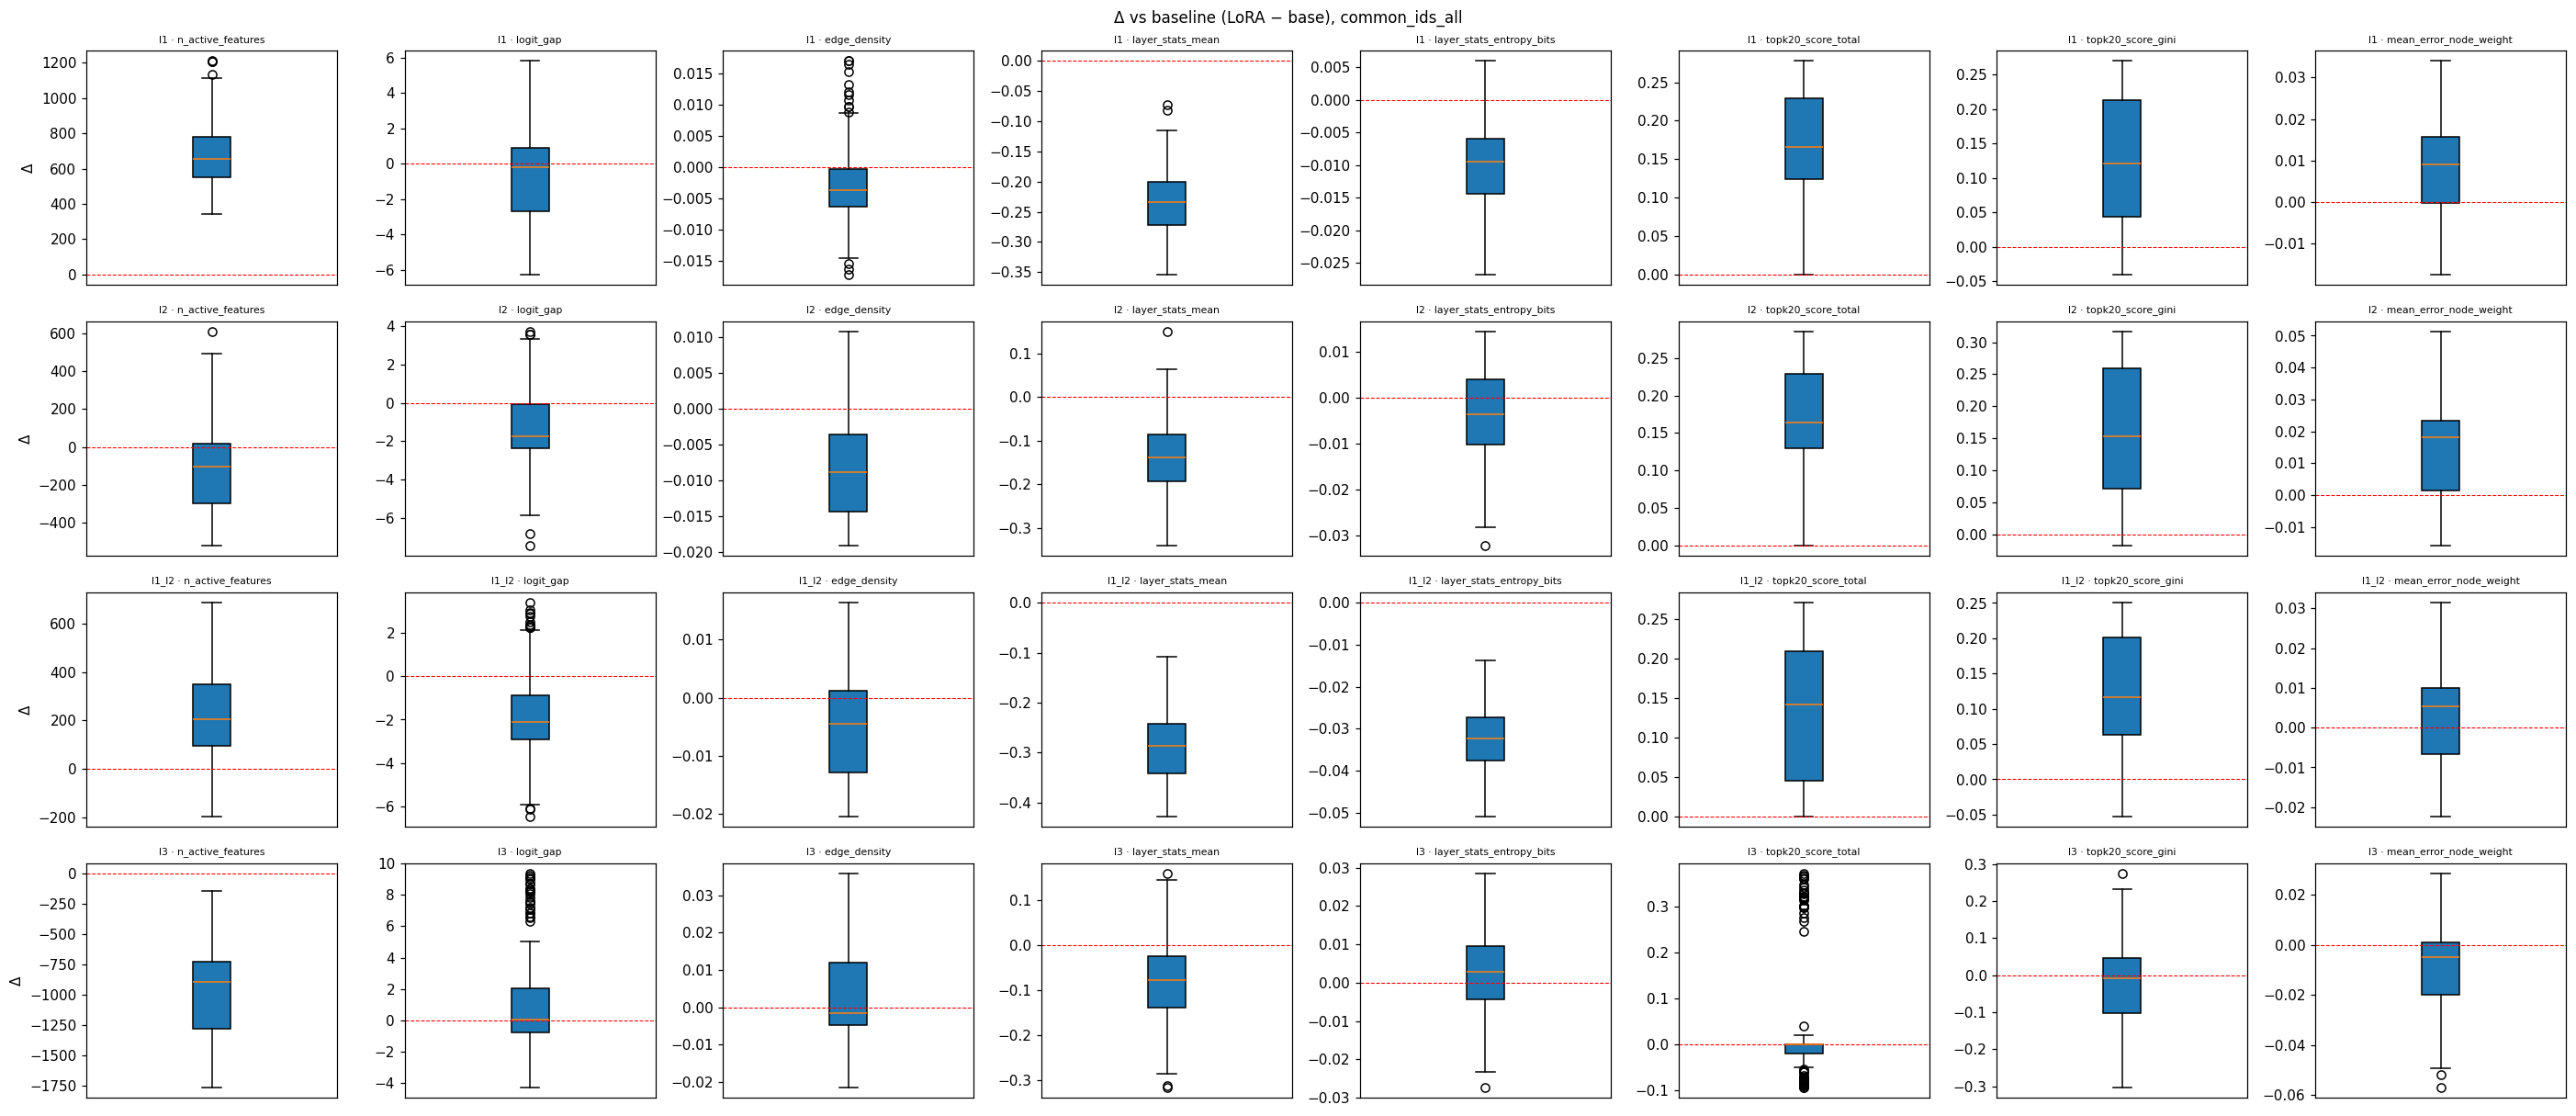

Saved: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison/delta_distributions_all_lora.png


In [6]:
plot_metrics = [m for m in KEY_METRICS if m in df_delta.columns]
if not plot_metrics:
    print("No KEY_METRICS in df_delta.")
else:
    n_l = len(LORA_PHASES)
    n_m = len(plot_metrics)
    fig, axes = plt.subplots(n_l, n_m, figsize=(3.2 * n_m, 2.8 * n_l), squeeze=False)
    for ri, lora_name in enumerate(LORA_PHASES):
        sub = df_delta[df_delta["phase"] == lora_name]
        for ci, dc in enumerate(plot_metrics):
            ax = axes[ri][ci]
            vals = sub[dc].dropna().values
            if len(vals):
                ax.boxplot(vals, vert=True, patch_artist=True)
                ax.axhline(0, color="red", linestyle="--", linewidth=0.7)
            ax.set_title(f"{lora_name} · {dc[2:]}", fontsize=7)
            if ci == 0:
                ax.set_ylabel("Δ")
            ax.set_xticks([])
    plt.suptitle("Δ vs baseline (LoRA − base), common_ids_all", fontsize=11)
    plt.tight_layout()
    p = FIGURES_DIR / "delta_distributions_all_lora.png"
    plt.savefig(p, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {p}")


## 6 — Top-20 Jaccard overlap (base vs each LoRA)

Jaccard between `(layer, feat_idx)` sets in `topk20.features`.


Jaccard vs baseline (top-20 feature sets)

  l1        mean=0.375  median=0.393  n=240
  l2        mean=0.354  median=0.385  n=240
  l1_l2     mean=0.349  median=0.379  n=240
  l3        mean=0.282  median=0.254  n=240


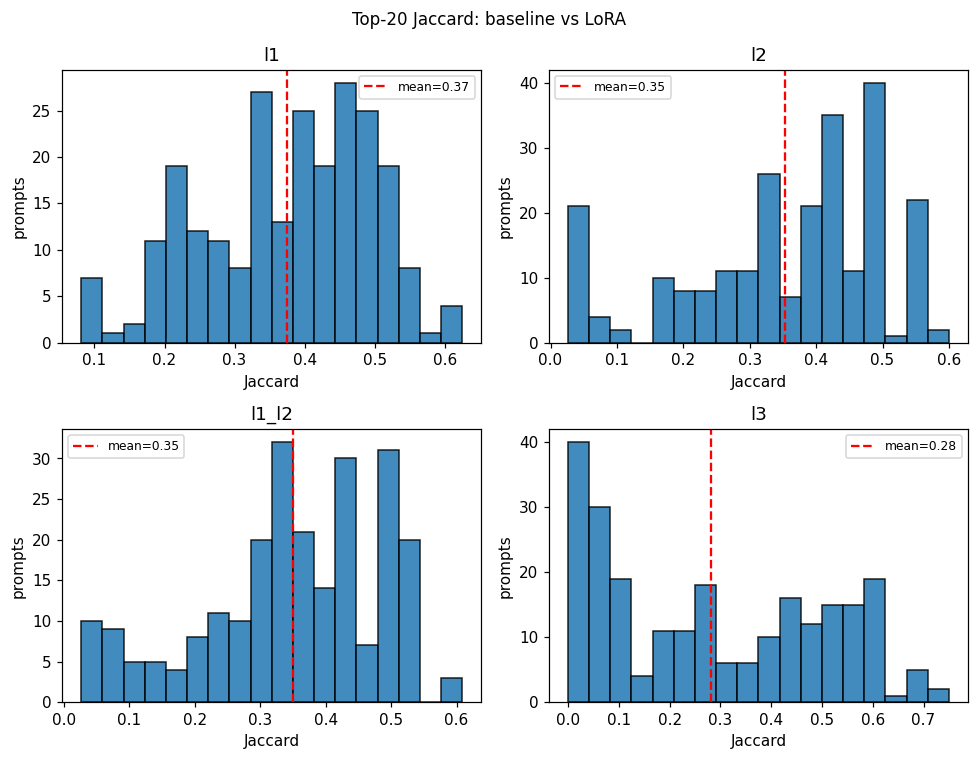

Saved: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison/jaccard_histogram_all_lora.png


In [7]:
def _topk_set(stat: dict) -> set:
    topk = stat.get("topk20")
    if not isinstance(topk, dict):
        return set()
    features = topk.get("features", [])
    return {(int(f["layer"]), int(f["feat_idx"])) for f in features if "layer" in f and "feat_idx" in f}


jaccard_parts = []
for lora_name in LORA_PHASES:
    rows = []
    for pid in common_ids:
        base_s = base_by_id[pid]
        lora_s = phase_stats_by_id[lora_name][pid]
        A, B = _topk_set(base_s), _topk_set(lora_s)
        if not A and not B:
            continue
        union = len(A | B)
        j = (len(A & B) / union) if union > 0 else float("nan")
        rows.append({"phase": lora_name, "prompt_id": pid, "jaccard": j,
                     "family": base_s.get("family"), "label": _label_str(base_s)})
    jaccard_parts.extend(rows)

df_jaccard = pd.DataFrame(jaccard_parts)
print("Jaccard vs baseline (top-20 feature sets)\n")
for lora_name in LORA_PHASES:
    sub = df_jaccard[df_jaccard["phase"] == lora_name]["jaccard"].dropna()
    if len(sub):
        print(f"  {lora_name:<8}  mean={sub.mean():.3f}  median={sub.median():.3f}  n={len(sub)}")

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, lora_name in zip(axes.flat, LORA_PHASES):
    sub = df_jaccard[df_jaccard["phase"] == lora_name]["jaccard"].dropna()
    if len(sub):
        ax.hist(sub, bins=18, edgecolor="k", alpha=0.85)
        ax.axvline(sub.mean(), color="red", linestyle="--", label=f"mean={sub.mean():.2f}")
    ax.set_title(lora_name)
    ax.set_xlabel("Jaccard")
    ax.set_ylabel("prompts")
    ax.legend(fontsize=8)
plt.suptitle("Top-20 Jaccard: baseline vs LoRA", fontsize=11)
plt.tight_layout()
p = FIGURES_DIR / "jaccard_histogram_all_lora.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")


## 7 — Logit gap: all phases


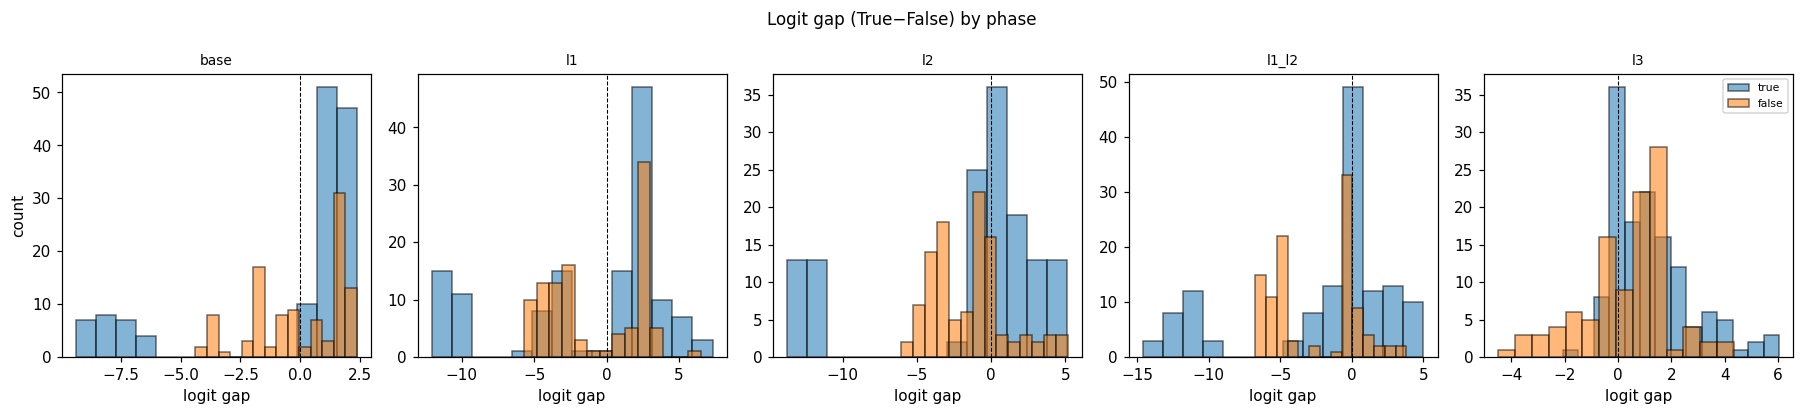

Saved: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison/logit_gap_all_phases.png


In [8]:
# Overlay distributions per phase (same prompts)
fig, axes = plt.subplots(1, len(PHASE_REGISTRY), figsize=(3.3 * len(PHASE_REGISTRY), 3.8), squeeze=False)

for ax, (phase_name, *_) in zip(axes[0], PHASE_REGISTRY):
    gaps = []
    labs = []
    for pid in common_ids:
        g = phase_stats_by_id[phase_name][pid].get("logit_gap")
        if g is None:
            continue
        gaps.append(float(g))
        labs.append(_label_str(phase_stats_by_id["base"][pid]))
    for lbl, c in [("true", "tab:blue"), ("false", "tab:orange")]:
        v = [g for g, lb in zip(gaps, labs) if lb == lbl]
        if v:
            ax.hist(v, bins=14, alpha=0.55, label=lbl, color=c, edgecolor="k")
    ax.axvline(0, color="k", linestyle="--", linewidth=0.7)
    ax.set_title(phase_name, fontsize=9)
    ax.set_xlabel("logit gap")
axes[0][0].set_ylabel("count")
axes[0][-1].legend(fontsize=7)
plt.suptitle("Logit gap (True−False) by phase", fontsize=11)
plt.tight_layout()
p = FIGURES_DIR / "logit_gap_all_phases.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")


## 8 — Leave-one-family-out: label + tail (§5 / §5b features)

Same protocol as `03_baseline_structural_analysis` §5 (layer_stats + prune) and §5b (layer_hist).
Runs for **every** phase: base, l1, l2, l1_l2, l3.


In [9]:
from utils.structural_classification import (
    build_feature_cols_layer_stats,
)

all_lofo_results: dict[str, dict] = {}

print("=" * 70)
print("LOFO classifiers (layer_stats + layer_hist × label + tail)")
print("=" * 70)

for phase_name, stat_paths, _pred, _bin_prob, _num_prob in PHASE_REGISTRY:
    by_id = phase_stats_by_id[phase_name]
    phase_raw = [by_id[pid] for pid in common_ids if pid in by_id]
    phase_flat = [_flatten_nested(r) for r in phase_raw]
    result = eval_phase_lofo(phase_raw, phase_flat, common_ids_all, phase_name)
    all_lofo_results[phase_name] = result

    print(f"\n--- {phase_name} (binary-TF n={result.get('n_total_filtered', '?')}) ---")
    if "error" in result:
        print(f"  ERROR: {result['error']}")
        continue
    for feat_mode in ("layer_stats", "layer_hist"):
        for target in ("label", "tail"):
            r = result.get((feat_mode, target), {})
            if "error" in r:
                print(f"  [{feat_mode}/{target}] {r['error']}")
                continue
            print(
                f"  [{feat_mode}/{target}] CV5={r['cv5_mean']:.1%}±{r['cv5_std']:.1%}  "
                f"meanLOO={r['mean_loo']:.1%}  (n={r['n']})"
            )


LOFO classifiers (layer_stats + layer_hist × label + tail)

--- base (binary-TF n=214) ---
  [layer_stats/label] CV5=79.5%±6.4%  meanLOO=57.6%  (n=214)
  [layer_stats/tail] CV5=98.6%±1.9%  meanLOO=63.5%  (n=214)
  [layer_hist/label] CV5=83.7%±5.0%  meanLOO=58.2%  (n=214)
  [layer_hist/tail] CV5=98.6%±1.9%  meanLOO=69.7%  (n=214)

--- l1 (binary-TF n=214) ---
  [layer_stats/label] CV5=81.4%±7.9%  meanLOO=53.8%  (n=214)
  [layer_stats/tail] CV5=97.2%±3.4%  meanLOO=75.6%  (n=214)
  [layer_hist/label] CV5=84.6%±5.4%  meanLOO=49.7%  (n=214)
  [layer_hist/tail] CV5=98.6%±1.9%  meanLOO=67.6%  (n=214)

--- l2 (binary-TF n=214) ---
  [layer_stats/label] CV5=81.3%±5.4%  meanLOO=55.1%  (n=214)
  [layer_stats/tail] CV5=97.2%±2.7%  meanLOO=80.8%  (n=214)
  [layer_hist/label] CV5=83.2%±6.1%  meanLOO=48.2%  (n=214)
  [layer_hist/tail] CV5=98.6%±1.1%  meanLOO=81.3%  (n=214)

--- l1_l2 (binary-TF n=214) ---
  [layer_stats/label] CV5=84.1%±4.2%  meanLOO=53.5%  (n=214)
  [layer_stats/tail] CV5=97.2%±1.7%

## 9 — LOFO summary table + chart + token CSV export


LOFO pivot: CV5 / meanLOO per phase

Phase         laye_label  laye_tail   laye_label  laye_tail 
base          79%/58%  99%/63%  84%/58%  99%/70%
l1            81%/54%  97%/76%  85%/50%  99%/68%
l2            81%/55%  97%/81%  83%/48%  99%/81%
l1_l2         84%/53%  97%/73%  88%/49%  98%/72%
l3            72%/51%  96%/52%  80%/52%  98%/59%


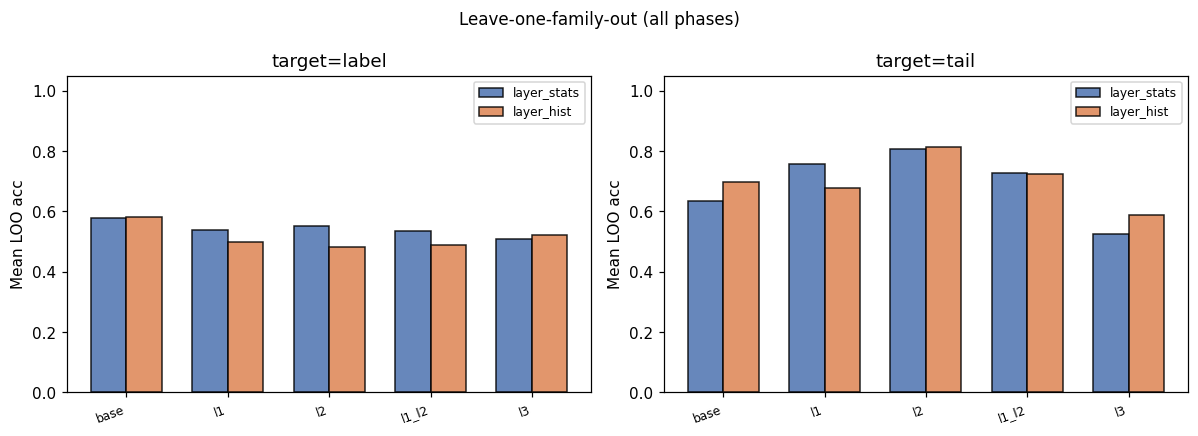

Saved: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison/lofo_multiPhase.png
Exported: lofo_summary.csv, lofo_loo_details.csv, first_token_multiPhase.csv, first_token_binary.csv, first_token_numeric.csv → /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison


In [10]:
summary_rows = []
loo_detail_rows = []

for phase_name, *_ in PHASE_REGISTRY:
    result = all_lofo_results.get(phase_name, {})
    if "error" in result:
        continue
    for feat_mode in ("layer_stats", "layer_hist"):
        for target in ("label", "tail"):
            key = (feat_mode, target)
            r = result.get(key, {})
            if "error" in r:
                continue
            summary_rows.append({
                "phase": phase_name, "feat_mode": feat_mode, "target": target,
                "n": r.get("n", 0), "majority": r.get("majority", float("nan")),
                "cv5_mean": r.get("cv5_mean", float("nan")),
                "cv5_std": r.get("cv5_std", float("nan")),
                "mean_loo": r.get("mean_loo", float("nan")),
                "n_classes": r.get("n_classes", 2),
            })
            for held, acc, note in r.get("loo_details", []):
                loo_detail_rows.append({
                    "phase": phase_name, "feat_mode": feat_mode, "target": target,
                    "held_out_family": held, "loo_acc": acc, "note": note,
                })

df_lofo = pd.DataFrame(summary_rows)
df_loo_details = pd.DataFrame(loo_detail_rows)

print("LOFO pivot: CV5 / meanLOO per phase\n")
feat_modes = ["layer_stats", "layer_hist"]
targets = ["label", "tail"]
print(f"{'Phase':<12}", end="")
for fm in feat_modes:
    for tgt in targets:
        print(f"  {fm[:4]}_{tgt:<5}", end="")
print()
for phase_name, *_ in PHASE_REGISTRY:
    print(f"{phase_name:<12}", end="")
    for fm in feat_modes:
        for tgt in targets:
            sub = df_lofo[(df_lofo["phase"] == phase_name) & (df_lofo["feat_mode"] == fm) & (df_lofo["target"] == tgt)]
            if sub.empty:
                print(f"  {'–':>12}", end="")
            else:
                r = sub.iloc[0]
                print(f"  {r['cv5_mean']:.0%}/{r['mean_loo']:.0%}", end="")
    print()

phase_order = [n for n, *_ in PHASE_REGISTRY]
colors = {"layer_stats": "#4C72B0", "layer_hist": "#DD8452"}
x = np.arange(len(phase_order))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax_i, target in enumerate(["label", "tail"]):
    ax = axes[ax_i]
    for j, feat_mode in enumerate(feat_modes):
        vals = []
        for ph in phase_order:
            sub = df_lofo[(df_lofo["phase"] == ph) & (df_lofo["feat_mode"] == feat_mode) & (df_lofo["target"] == target)]
            vals.append(sub.iloc[0]["mean_loo"] if not sub.empty else float("nan"))
        ax.bar(x + (j - 0.5) * width, vals, width, label=feat_mode, color=colors[feat_mode], alpha=0.85, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels(phase_order, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Mean LOO acc")
    ax.set_title(f"target={target}")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
plt.suptitle("Leave-one-family-out (all phases)", fontsize=11)
plt.tight_layout()
p = FIGURES_DIR / "lofo_multiPhase.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

df_lofo.to_csv(FIGURES_DIR / "lofo_summary.csv", index=False)
df_loo_details.to_csv(FIGURES_DIR / "lofo_loo_details.csv", index=False)
df_token.to_csv(FIGURES_DIR / "first_token_multiPhase.csv")
df_token_binary.to_csv(FIGURES_DIR / "first_token_binary.csv")
df_token_numeric.to_csv(FIGURES_DIR / "first_token_numeric.csv")
print(
    f"Exported: lofo_summary.csv, lofo_loo_details.csv, first_token_multiPhase.csv, "
    f"first_token_binary.csv, first_token_numeric.csv → {FIGURES_DIR}"
)


## 10 — Thesis summary: means + effect sizes (Δ vs base)


In [11]:
THESIS_METRICS = [
    "n_active_features", "edge_density", "logit_gap",
    "layer_stats_mean", "layer_stats_entropy_bits", "topk20_score_total",
]

print(f"{'Metric':<28}", end="")
for lp in LORA_PHASES:
    print(f"  {lp:>12}", end="")
print(f"  {'|Δ|/σ_avg':>12}")
print("-" * (28 + 14 * (len(LORA_PHASES) + 1)))

base_flat_all = [_flatten_nested(base_by_id[pid]) for pid in common_ids]

for m in THESIS_METRICS:
    print(f"{m:<28}", end="")
    base_vals = np.array([float(f[m]) for f in base_flat_all if f.get(m) is not None])
    sigma_b = float(np.std(base_vals)) if len(base_vals) else float("nan")
    effs = []
    for lp in LORA_PHASES:
        sub = df_delta[df_delta["phase"] == lp][f"d_{m}"].dropna()
        if len(sub) == 0 or not sigma_b or np.isnan(sigma_b):
            print(f"  {'N/A':>12}", end="")
            effs.append(float("nan"))
        else:
            dmean = float(sub.mean())
            print(f"  {dmean:>+12.4f}", end="")
            effs.append(abs(dmean) / sigma_b)
    avg_eff = np.nanmean(effs) if effs else float("nan")
    print(f"  {avg_eff:>12.3f}" if not np.isnan(avg_eff) else f"  {'N/A':>12}")

print()
print("|Δ|/σ: avg abs mean-Δ across LoRAs / σ(base); σ from baseline on common_ids.")


Metric                                  l1            l2         l1_l2            l3     |Δ|/σ_avg
--------------------------------------------------------------------------------------------------
n_active_features                +680.5042     -119.4958     +225.5042     -977.1208         0.101
edge_density                       -0.0027       -0.0079       -0.0048       +0.0030         0.899
logit_gap                          -0.6933       -1.2430       -1.8902       +1.1117         0.402
layer_stats_mean                   -0.2334       -0.1377       -0.2919       -0.0757         0.711
layer_stats_entropy_bits           -0.0103       -0.0037       -0.0323       +0.0028         0.386
topk20_score_total                 +0.1658       +0.1632       +0.1246       +0.0209         4.757

|Δ|/σ: avg abs mean-Δ across LoRAs / σ(base); σ from baseline on common_ids.


## 11 — Export remaining artifacts


In [12]:
df_delta.to_csv(FIGURES_DIR / "lora_delta_per_prompt_all_phases.csv", index=False)
print(f"Saved lora_delta_per_prompt_all_phases.csv ({len(df_delta)} rows)")

if not df_delta.empty:
    gcols = ["phase", "family", "label", "tail"]
    summ = df_delta.groupby(gcols)[[c for c in delta_cols if c in df_delta.columns]].mean()
    summ.to_csv(FIGURES_DIR / "lora_delta_summary_by_group.csv")
    print("Saved lora_delta_summary_by_group.csv")

df_all_deltas = df_delta  # alias for scripts expecting this name

if not df_jaccard.empty:
    df_jaccard.to_csv(FIGURES_DIR / "jaccard_per_prompt_all_phases.csv", index=False)
    print("Saved jaccard_per_prompt_all_phases.csv")

print()
print("All outputs in:", FIGURES_DIR)


Saved lora_delta_per_prompt_all_phases.csv (960 rows)
Saved lora_delta_summary_by_group.csv
Saved jaccard_per_prompt_all_phases.csv

All outputs in: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison
